# **Project Title: Predicting divorce**
by Kabir, Rodrigue and Sertac

**Research main objective**

This project aims to critically examine the informational requirements for machine learning–based divorce prediction, by evaluating which categories of variables (demographic, socioeconomic, relational, and psychological carry sufficient predictive signal, and identifying the data gaps that limit model performance when only cross-sectional, population-level features are available. 

Specifically, it seeks at 

- Evaluate the limitations of standard multidimensional features (demographic, socioeconomic, and self-reported relational metrics) in accurately predicting marital dissolution.
- Identify which feature domains (if any) contribute the most consistent signal across models, using cross-model feature importance analysis.
- Propose variable types that the divorce prediction literature identifies as truly discriminative.


**Research questions**

- Why do traditional multidimensional determinants yield such modest predictive performance (approximately 60% accuracy) in divorce classification models?
-  Among the features utilized, which specific categories exhibit the highest relative importance, and what does their overall lack of explanatory power reveal about the complexities of divorce?
- What novel types of data are theoretically required to build a genuinely robust predictive model?


**Methods**
-	Exploration of the dataset 
-	Preparation of the dataset
-	Training and comparison of supervised learning models
-	Identification of  the most important predictors of divorce


In [1]:
#Load libraries that will be used throughout the project (will be continuouysly updated)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    roc_curve,
    auc
)
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.tab_model import TabNetClassifier
import copy



In [2]:
# Load the dataset
df = pd.read_csv('divorce_df.csv')
df.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,Yes,5.536016,3,...,No,No,No,8.428183,5,Love,Yes,No,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,Yes,5.810172,3,...,No,Yes,No,5.297221,1,Love,Yes,No,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,No,6.088146,3,...,No,No,No,5.887066,1,Arranged,Yes,No,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,Yes,6.212046,3,...,No,No,No,5.263555,5,Love,Yes,No,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,Yes,4.826262,1,...,No,No,Yes,5.771259,4,Love,Yes,No,10.000000,1


In [3]:
# Make a copy of the original dataset
df1 = df.copy()
df1.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,Yes,5.536016,3,...,No,No,No,8.428183,5,Love,Yes,No,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,Yes,5.810172,3,...,No,Yes,No,5.297221,1,Love,Yes,No,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,No,6.088146,3,...,No,No,No,5.887066,1,Arranged,Yes,No,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,Yes,6.212046,3,...,No,No,No,5.263555,5,Love,Yes,No,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,Yes,4.826262,1,...,No,No,Yes,5.771259,4,Love,Yes,No,10.000000,1


In [4]:
#Show the list of columns in the dataset
df1.columns

Index(['age_at_marriage', 'marriage_duration_years', 'num_children',
       'education_level', 'employment_status', 'combined_income',
       'religious_compatibility', 'cultural_background_match',
       'communication_score', 'conflict_frequency',
       'conflict_resolution_style', 'financial_stress_level',
       'mental_health_issues', 'infidelity_occurred', 'counseling_attended',
       'social_support', 'shared_hobbies_count', 'marriage_type',
       'pre_marital_cohabitation', 'domestic_violence_history', 'trust_score',
       'divorced'],
      dtype='object')

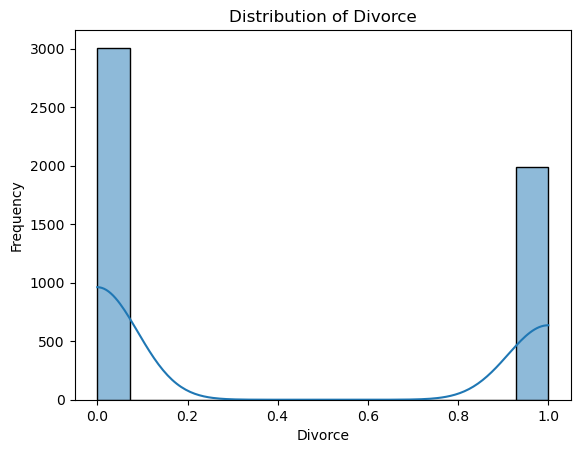

In [5]:
#Histogram of the target variable 
sns.histplot(df1['divorced'], kde=True)
plt.title('Distribution of Divorce')
plt.xlabel('Divorce')
plt.ylabel('Frequency')
plt.show()

       age_at_marriage  marriage_duration_years  num_children  \
count      5000.000000              5000.000000   5000.000000   
mean         27.583600                 9.171000      1.552800   
std           4.855978                 8.848266      1.247527   
min          18.000000                 1.000000      0.000000   
25%          24.000000                 2.000000      1.000000   
50%          28.000000                 6.000000      1.000000   
75%          31.000000                13.000000      2.000000   
max          45.000000                40.000000      6.000000   

       combined_income  communication_score  conflict_frequency  \
count      5000.000000          5000.000000         5000.000000   
mean      60220.078400             6.040507            2.008000   
std       19662.080982             1.963349            1.412351   
min       10000.000000             1.000000            0.000000   
25%       46666.000000             4.661929            1.000000   
50%       60

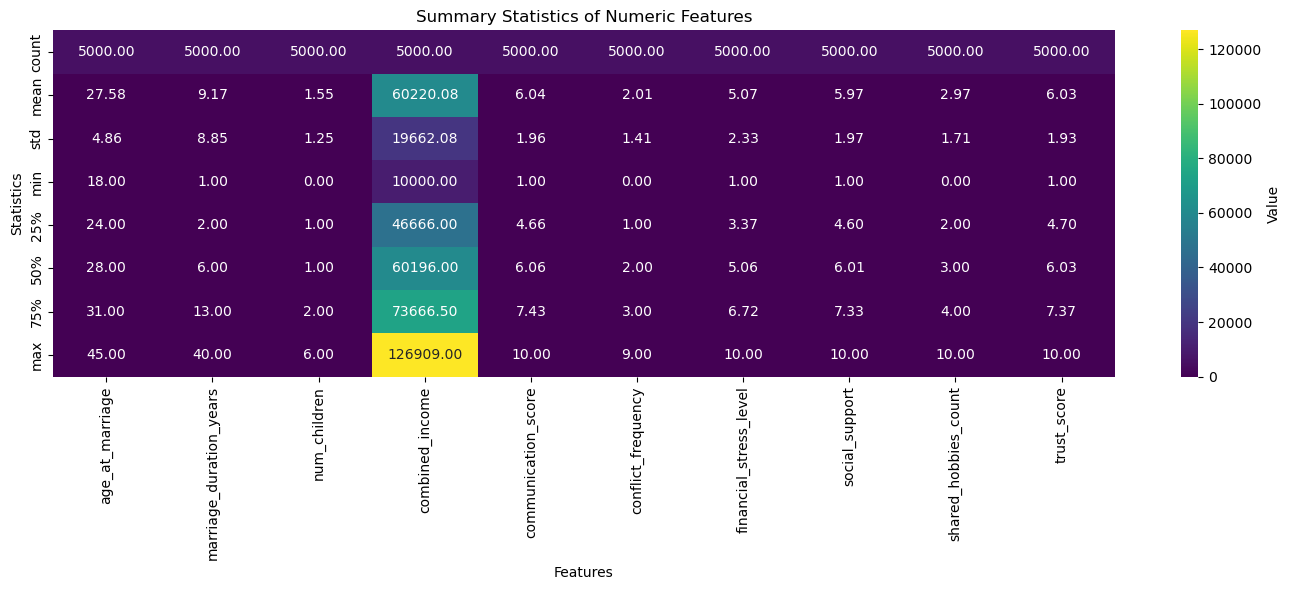

In [11]:
# Produce summary statistics of the numeric features only
numeric_df = df1.drop('divorced', axis=1).select_dtypes(include=['number'])
summary_stats = numeric_df.describe()
print(summary_stats)

# Plotting the summary statistics into a heatmap for better visualization
plt.figure(figsize=(14, 6))
sns.heatmap(summary_stats, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'Value'})
plt.title('Summary Statistics of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Statistics')
plt.tight_layout()
plt.show()

C:\Users\kabir\AppData\Local\Temp\ipykernel_26180\3270925871.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  consolidated_table = consolidated_table.fillna(0).astype(int)


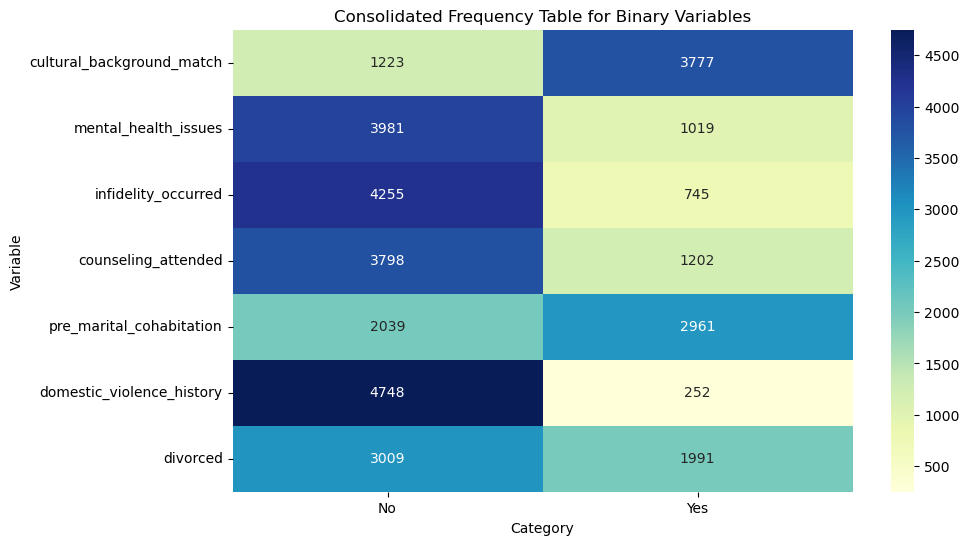

Consolidated Frequency Table:
                             No   Yes
cultural_background_match  1223  3777
mental_health_issues       3981  1019
infidelity_occurred        4255   745
counseling_attended        3798  1202
pre_marital_cohabitation   2039  2961
domestic_violence_history  4748   252
divorced                   3009  1991


In [19]:
# Generating consolidated frequency table for binary variables
binary_columns = ['cultural_background_match','mental_health_issues','infidelity_occurred','counseling_attended','pre_marital_cohabitation','domestic_violence_history','divorced']

#Creating a plot for the table 
consolidated_table = pd.DataFrame(columns=[0, 1])
for col in binary_columns:
    vc = df1[col].value_counts()
    for cat, count in vc.items():
        if cat == 'Yes' or cat == 1:
            consolidated_table.loc[col, 1] = count
        elif cat == 'No' or cat == 0:
            consolidated_table.loc[col, 0] = count

consolidated_table = consolidated_table.fillna(0).astype(int)
consolidated_table = consolidated_table.rename(columns={0: 'No', 1: 'Yes'})
plt.figure(figsize=(10, 6))
sns.heatmap(consolidated_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Consolidated Frequency Table for Binary Variables')
plt.xlabel('Category')
plt.ylabel('Variable')
plt.show()

print("Consolidated Frequency Table:")
print(consolidated_table)

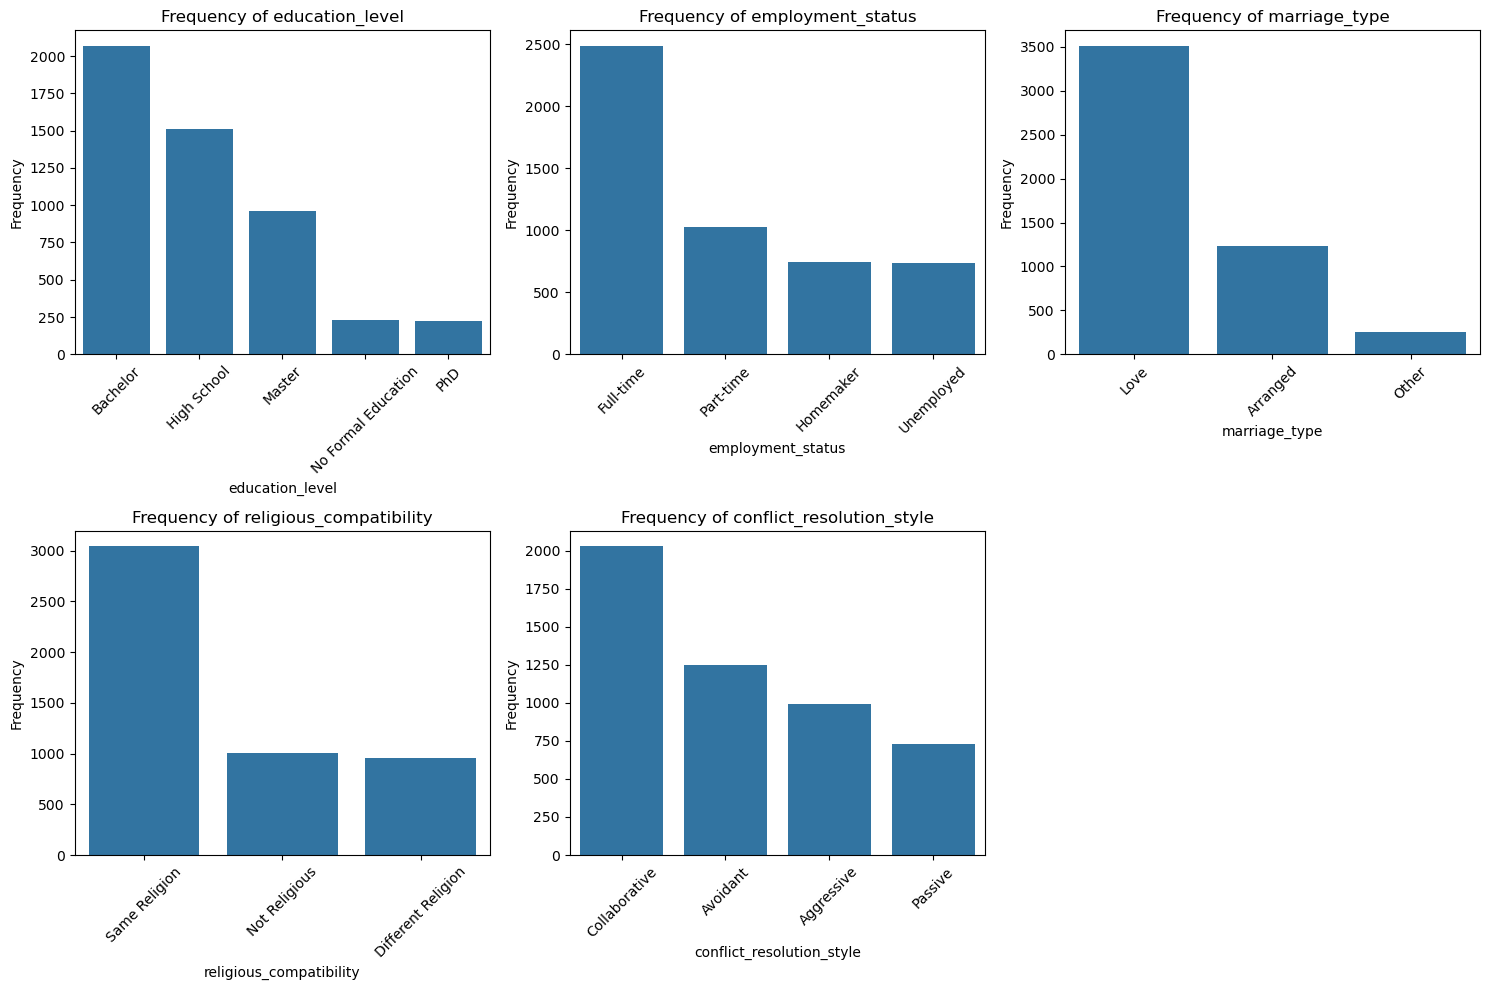

In [26]:
#Generating frequency tables for multi categorical variables
multi_categorical_columns = ['education_level', 'employment_status', 'marriage_type', 'religious_compatibility', 'conflict_resolution_style']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten to make it easier to iterate

for idx, col in enumerate(multi_categorical_columns):
    sns.countplot(data=df1, x=col, order=df1[col].value_counts().index, ax=axes[idx])
    axes[idx].set_title(f'Frequency of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].tick_params(axis='x', rotation=45)

# Hide the extra subplot (since we have 5 columns but 6 subplots in 2x3)
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
# Check for missing values
df1.isnull().sum()

age_at_marriage              0
marriage_duration_years      0
num_children                 0
education_level              0
employment_status            0
combined_income              0
religious_compatibility      0
cultural_background_match    0
communication_score          0
conflict_frequency           0
conflict_resolution_style    0
financial_stress_level       0
mental_health_issues         0
infidelity_occurred          0
counseling_attended          0
social_support               0
shared_hobbies_count         0
marriage_type                0
pre_marital_cohabitation     0
domestic_violence_history    0
trust_score                  0
divorced                     0
dtype: int64

**Pre-processing and preparation of the dataset for machine learning**

In [11]:
X = df1[
    [
        'age_at_marriage',
        'marriage_duration_years',
        'num_children',
        'education_level',
        'employment_status',
        'combined_income',
        'religious_compatibility',
        'cultural_background_match',
        'communication_score',
        'conflict_frequency',
        'conflict_resolution_style',
        'financial_stress_level',
        'mental_health_issues',
        'infidelity_occurred',
        'counseling_attended',
        'social_support',
        'shared_hobbies_count',
        'marriage_type',
        'pre_marital_cohabitation',
        'domestic_violence_history',
        'trust_score'
    ]
]

y = df1['divorced']

# ==========================================
# TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==========================================
# DISPLAY SPLIT INFORMATION
# ==========================================

print(f"\n--- Dataset Split Results ---")
print(f"Total samples: {len(df1)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print("\nTraining Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Distribution:")
print(y_test.value_counts(normalize=True))

print(f"-----------------------------\n")



--- Dataset Split Results ---
Total samples: 5000
X_train shape: (4000, 21)
X_test shape: (1000, 21)

Training Distribution:
divorced
0    0.60175
1    0.39825
Name: proportion, dtype: float64

Testing Distribution:
divorced
0    0.602
1    0.398
Name: proportion, dtype: float64
-----------------------------



In [12]:
# ==========================================
# DEFINE NUMERICAL & CATEGORICAL FEATURES
# ==========================================

numerical_features = [
    'age_at_marriage',
    'marriage_duration_years',
    'num_children',
    'combined_income',
    'communication_score',
    'conflict_frequency',
    'financial_stress_level',
    'social_support',
    'shared_hobbies_count',
    'trust_score'
]

categorical_features = [
    'education_level',
    'employment_status',
    'religious_compatibility',
    'cultural_background_match',
    'conflict_resolution_style',
    'infidelity_occurred',
    'counseling_attended',
    'marriage_type',
    'pre_marital_cohabitation',
    'domestic_violence_history',
    'mental_health_issues'
]


# ==========================================
# PREPROCESSING
# ==========================================

numerical_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

smote_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)


In [13]:
# APPLY PREPROCESSING + SMOTE MANUALLY
# (FOR CHECKING CLASS DISTRIBUTION)
# ==========================================

# Preprocess training data
X_train_processed = smote_preprocessor.fit_transform(X_train)

# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

# Display class balance
print("Before SMOTE:")
print(Counter(y_train))

print("\nAfter SMOTE:")
print(Counter(y_train_smote))


Before SMOTE:
Counter({0: 2407, 1: 1593})

After SMOTE:
Counter({0: 2407, 1: 2407})


In [14]:
# BUILD SMOTE + LOGISTIC REGRESSION PIPELINE
# ==========================================

smote_pipeline = ImbPipeline(
    steps=[
        ('preprocessor', smote_preprocessor),

        ('smote', SMOTE(random_state=42)),

        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

**Machine learning models**

Model1: Logistic Regression


--- Training Model (Logistic Regression Classifier) ---
Making predictions for the following 5 couples:
   age_at_marriage  marriage_duration_years  num_children      education_level employment_status  combined_income religious_compatibility cultural_background_match  communication_score  conflict_frequency conflict_resolution_style  financial_stress_level mental_health_issues infidelity_occurred counseling_attended  social_support  shared_hobbies_count marriage_type pre_marital_cohabitation domestic_violence_history  trust_score
0               30                        1             1             Bachelor         Full-time            64001      Different Religion                       Yes             5.536016                   3             Collaborative                6.026355                   No                  No                  No        8.428183                     5          Love                      Yes                        No     6.262411
1               27             

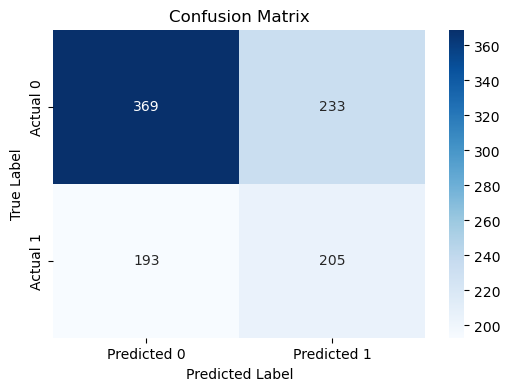


Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.61      0.63       602
           1       0.47      0.52      0.49       398

    accuracy                           0.57      1000
   macro avg       0.56      0.56      0.56      1000
weighted avg       0.58      0.57      0.58      1000



In [15]:
# Use the already-trained SMOTE pipeline for logistic regression
# This pipeline includes preprocessing, SMOTE oversampling, and the classifier.
divorce_model1 = smote_pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = divorce_model1.predict(X_test) 

# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (Logistic Regression Classifier) ---")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)
print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model1.predict(X.head()))

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])    
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred))



C:\Users\kabir\AppData\Local\Temp\ipykernel_9132\2019471720.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


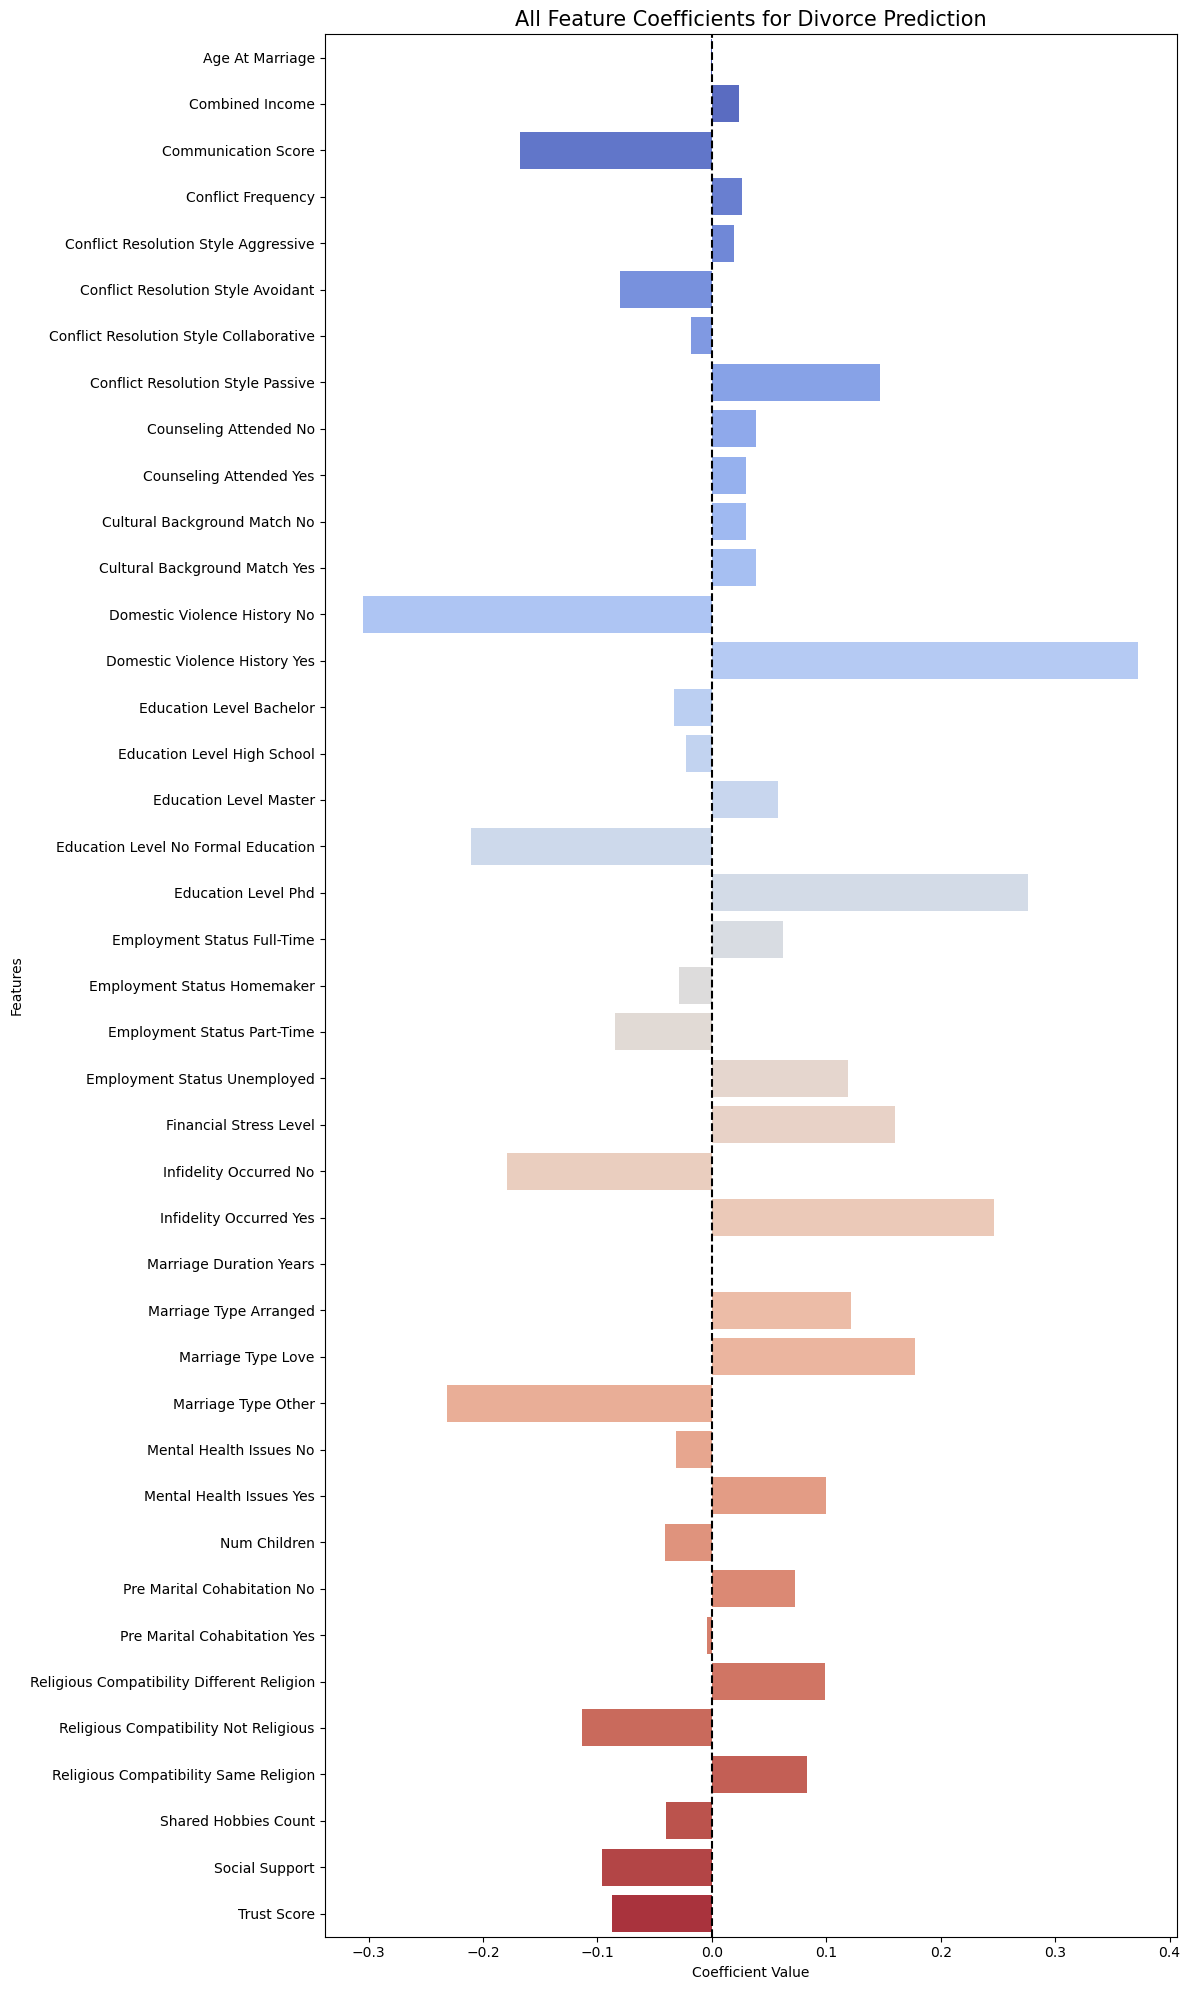

In [16]:
# Get model
logistic_model = divorce_model1.named_steps['classifier']

# Feature names
feature_names_num = numerical_features

feature_names_cat = divorce_model1.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_features)

all_feature_names = list(feature_names_num) + list(feature_names_cat)

# Coefficients
coefficients = logistic_model.coef_[0]

# Build dataframe
feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})

# Make labels readable
plot_features = feature_importance.copy()
plot_features['Feature'] = (
    plot_features['Feature']
    .str.replace('_',' ')
    .str.title()
)

# Sort alphabetically
plot_features = plot_features.sort_values(by='Feature')

# Plot
plt.figure(figsize=(12,20))

sns.barplot(
    data=plot_features,
    x='Coefficient',
    y='Feature',
    palette='coolwarm'
)

plt.axvline(
    0,
    color='black',
    linestyle='--'
)

plt.title(
    'All Feature Coefficients for Divorce Prediction',
    fontsize=15
)

plt.xlabel(
    'Coefficient Value'
)

plt.ylabel(
    'Features'
)

plt.tight_layout()

plt.show()

Model2: Random Forest Classifier


--- Training Model (Random Forest Classifier) ---
Making predictions for the following 5 couples:
   age_at_marriage  marriage_duration_years  num_children      education_level employment_status  combined_income religious_compatibility cultural_background_match  communication_score  conflict_frequency conflict_resolution_style  financial_stress_level mental_health_issues infidelity_occurred counseling_attended  social_support  shared_hobbies_count marriage_type pre_marital_cohabitation domestic_violence_history  trust_score
0               30                        1             1             Bachelor         Full-time            64001      Different Religion                       Yes             5.536016                   3             Collaborative                6.026355                   No                  No                  No        8.428183                     5          Love                      Yes                        No     6.262411
1               27                   

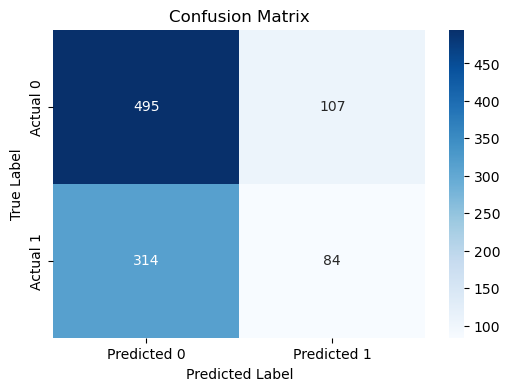


Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.82      0.70       602
           1       0.44      0.21      0.29       398

    accuracy                           0.58      1000
   macro avg       0.53      0.52      0.49      1000
weighted avg       0.54      0.58      0.54      1000



In [17]:
# Define Random Forest model with SMOTE

divorce_model2 = ImbPipeline(
    steps=[
        ('preprocessor', smote_preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            random_state=42
        ))
    ]
)

# Train the model
divorce_model2.fit(X_train, y_train) 

# Predict on the test set
y_pred = divorce_model2.predict(X_test) 

# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (Random Forest Classifier) ---")

print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model2.predict(X.head()))

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])    
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred))

C:\Users\kabir\AppData\Local\Temp\ipykernel_9132\2128857191.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


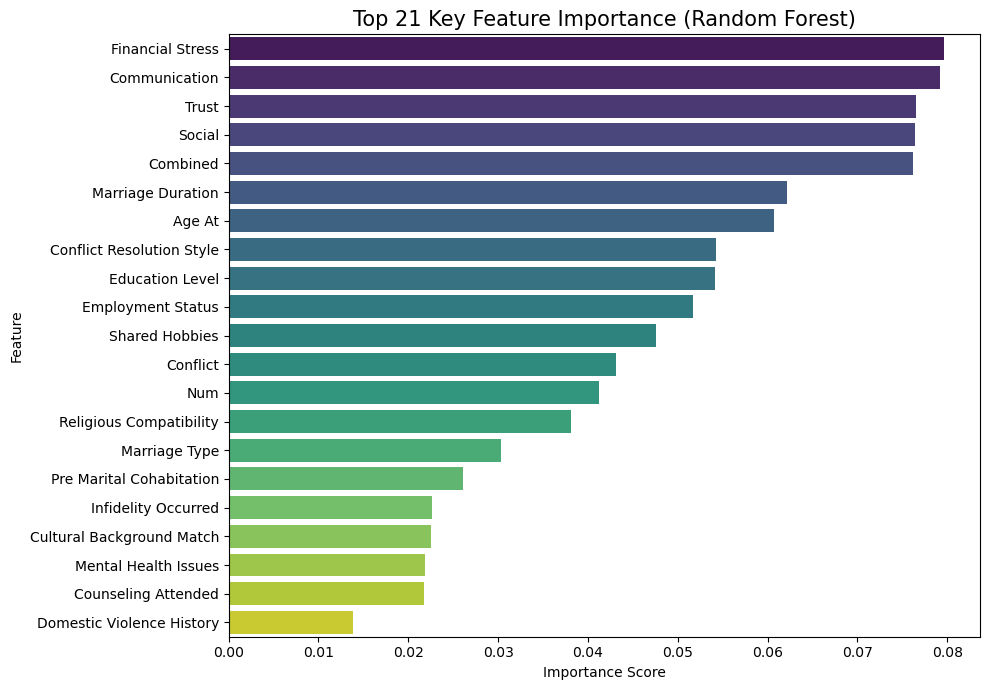

In [18]:
# Get trained Random Forest
rf_model = divorce_model2.named_steps['classifier']


# Get feature names
feature_names_num = numerical_features

feature_names_cat = divorce_model2.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_features)

all_feature_names = list(feature_names_num) + list(feature_names_cat)


# Importance
importance = rf_model.feature_importances_


feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importance
})


# Clean names and combine all dummies for the same original feature
feature_importance['Feature'] = feature_importance['Feature'].apply(
    lambda x: x.rsplit('_', 1)[0].replace('_', ' ').title() if '_' in x else x.replace('_', ' ').title()
)


# Combine duplicated features by summing importance
feature_importance = (
    feature_importance
    .groupby('Feature', as_index=False)
    ['Importance']
    .sum()
)


# Sort by importance and select top 20
plot_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(21)


# Plot
plt.figure(figsize=(10,7))

sns.barplot(
    data=plot_features,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title(
    'Top 21 Key Feature Importance (Random Forest)',
    fontsize=15
)

plt.xlabel(
    'Importance Score'
)

plt.ylabel(
    'Feature'
)

plt.tight_layout()

plt.show()

Model3: XGBoost Classifier


--- Training Model (XGBoost Classifier) ---

Making predictions for the following 5 couples:
   age_at_marriage  marriage_duration_years  num_children      education_level employment_status  combined_income religious_compatibility cultural_background_match  communication_score  conflict_frequency conflict_resolution_style  financial_stress_level mental_health_issues infidelity_occurred counseling_attended  social_support  shared_hobbies_count marriage_type pre_marital_cohabitation domestic_violence_history  trust_score
0               30                        1             1             Bachelor         Full-time            64001      Different Religion                       Yes             5.536016                   3             Collaborative                6.026355                   No                  No                  No        8.428183                     5          Love                      Yes                        No     6.262411
1               27                        

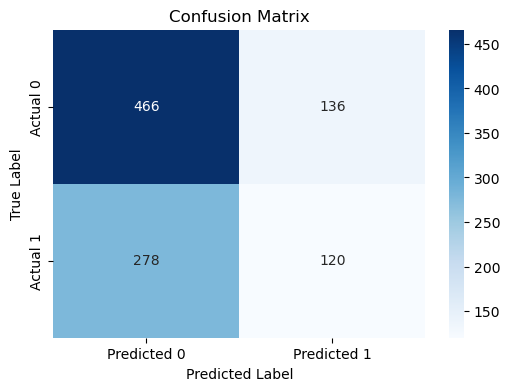


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.77      0.69       602
           1       0.47      0.30      0.37       398

    accuracy                           0.59      1000
   macro avg       0.55      0.54      0.53      1000
weighted avg       0.56      0.59      0.56      1000



In [19]:
# Define XGBoost model with SMOTE
divorce_model3 = ImbPipeline(
    steps=[
         ('preprocessor', smote_preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', XGBClassifier(
            n_estimators=500,
            max_depth=7,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            eval_metric='logloss'
        ))
    ]
)


# ==========================================
# TRAIN MODEL
# ==========================================

divorce_model3.fit(X_train, y_train)


# ==========================================
# PREDICT ON TEST SET
# ==========================================

y_pred = divorce_model3.predict(X_test)


# ==========================================
# MODEL EVALUATION
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (XGBoost Classifier) ---")


# ==========================================
# SAMPLE PREDICTIONS
# ==========================================

print("\nMaking predictions for the following 5 couples:")

print(X.head())

print("\nPredictions:")

print(divorce_model3.predict(X.head()))


# ==========================================
# CONFUSION MATRIX
# ==========================================

print("\n--- Confusion Matrix ---")

plt.figure(figsize=(6, 4))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()


# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

C:\Users\kabir\AppData\Local\Temp\ipykernel_9132\1729672684.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


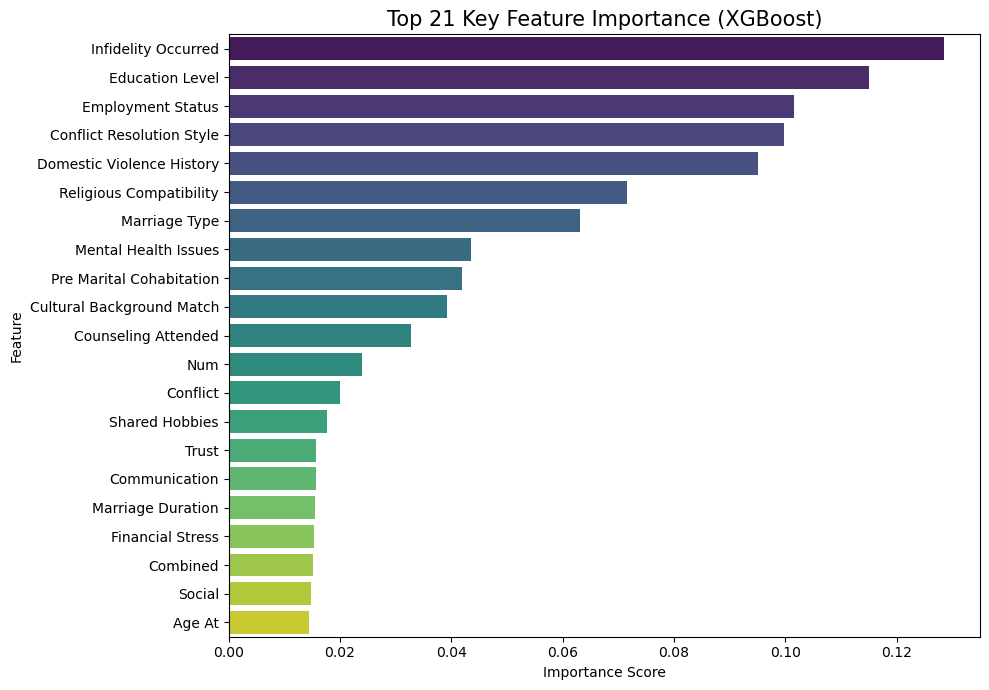

In [20]:
# Get trained XGBoost
xgb_model = divorce_model3.named_steps['classifier']


# Get feature names
feature_names_num = numerical_features

feature_names_cat = divorce_model3.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_features)

all_feature_names = list(feature_names_num) + list(feature_names_cat)


# Importance
importance = xgb_model.feature_importances_


feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importance
})


# Clean names and combine all dummies for the same original feature
feature_importance['Feature'] = feature_importance['Feature'].apply(
    lambda x: x.rsplit('_', 1)[0].replace('_', ' ').title() if '_' in x else x.replace('_', ' ').title()
)


# Combine duplicated features by summing importance
feature_importance = (
    feature_importance
    .groupby('Feature', as_index=False)
    ['Importance']
    .sum()
)


# Sort by importance and select top 20
plot_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(21)


# Plot
plt.figure(figsize=(10,7))

sns.barplot(
    data=plot_features,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title(
    'Top 21 Key Feature Importance (XGBoost)',
    fontsize=15
)

plt.xlabel(
    'Importance Score'
)

plt.ylabel(
    'Feature'
)

plt.tight_layout()

plt.show()

## Deep Learning

Model1: Neural Network Deep Forward with 32 Neurons & 64 Neurons

In [21]:
import random

# set random seeds for pytorch, numpy, and paython's built-in random module for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [23]:
# Starting from the output of the preprocessing pipeline
X_train_processed = smote_preprocessor.fit_transform(X_train)
X_test_processed = smote_preprocessor.transform(X_test)

In [24]:
# Split the training data into a smaller training set and a validation set
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_train_processed, y_train, test_size=0.2, random_state=42
)

In [25]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_full, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_full.values, dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)



In [26]:
# Define the model_32 (A simple feedforward neural network)
#input_size = X_train_tensor.shape[1]

model_32 = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    #nn.Sigmoid()
)


In [27]:
# Define the model_32a (A simple feedforward neural network)
#input_size = X_train_tensor.shape[1]

model_32a = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 32),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Dropout(0.3),
    
    nn.Linear(16, 1),
    #nn.Sigmoid()
)


In [28]:
# Define the model_64 (An improved version of Model_32)
model_64 = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 64),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    
    nn.Linear(32, 1),

)

In [29]:
#Defining model 64a (An improved version of Model_64)
model_64a = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 64),
    nn.ReLU(),
    

    nn.Linear(64, 32),
    nn.ReLU(),
    
    
    nn.Linear(32, 16),
    nn.ReLU(),
    
    
    nn.Linear(16, 1),

)


In [30]:
# Loss and Optimizer (both for model_32 and model_64)
pos_weight = torch.tensor([602/398])  # Calculate the ratio of negative to positive samples
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # Binary Cross Entropy with Logits (more stable)

optimizer_32 = optim.Adam(model_32.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_32a = optim.Adam(model_32a.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_64 = optim.Adam(model_64.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_64a = optim.Adam(model_64a.parameters(), lr=0.001, weight_decay=1e-4)

In [31]:
# Training Loop with Early Stopping

def train_model(model, optimizer, epochs = 100, patience = 15):
    
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_model_state = None
    counter = 0
    

    for epoch in range(epochs):

        # TRAIN
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # VALIDATION
        model.eval()
        with torch.no_grad():
             val_outputs = model(X_val_tensor)   # or X_val_tensor if you have a validation split
             val_loss = criterion(val_outputs, y_val_tensor)
    
        val_losses.append(val_loss.item())

        # EARLY STOPPING
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break


        if (epoch+1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

     # restore best model
    model.load_state_dict(best_model_state)

    return train_losses, val_losses, model

In [32]:
# train the models
train_32, val_32, model_32 = train_model(model_32, optimizer_32)
train_32a, val_32a, model_32a = train_model(model_32a, optimizer_32a)
train_64, val_64, model_64 = train_model(model_64, optimizer_64)
train_64a, val_64a, model_64a = train_model(model_64a, optimizer_64a)

Epoch [10/100], Train Loss: 0.8376, Val Loss: 0.8369
Epoch [20/100], Train Loss: 0.8335, Val Loss: 0.8328
Epoch [30/100], Train Loss: 0.8305, Val Loss: 0.8305
Epoch [40/100], Train Loss: 0.8267, Val Loss: 0.8286
Epoch [50/100], Train Loss: 0.8219, Val Loss: 0.8271
Epoch [60/100], Train Loss: 0.8163, Val Loss: 0.8261
Epoch [70/100], Train Loss: 0.8106, Val Loss: 0.8259
Epoch [80/100], Train Loss: 0.8049, Val Loss: 0.8269
Early stopping at epoch 84
Epoch [10/100], Train Loss: 0.8328, Val Loss: 0.8299
Epoch [20/100], Train Loss: 0.8315, Val Loss: 0.8283
Epoch [30/100], Train Loss: 0.8278, Val Loss: 0.8267
Epoch [40/100], Train Loss: 0.8262, Val Loss: 0.8252
Epoch [50/100], Train Loss: 0.8235, Val Loss: 0.8239
Epoch [60/100], Train Loss: 0.8202, Val Loss: 0.8233
Epoch [70/100], Train Loss: 0.8224, Val Loss: 0.8233
Epoch [80/100], Train Loss: 0.8134, Val Loss: 0.8229
Epoch [90/100], Train Loss: 0.8128, Val Loss: 0.8236
Early stopping at epoch 93
Epoch [10/100], Train Loss: 0.8309, Val Loss:

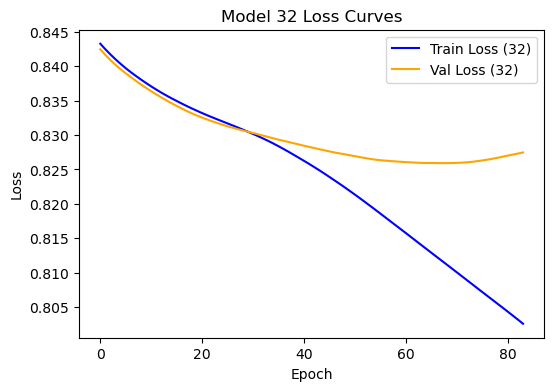

In [33]:
# Loss Curves for model_32
plt.figure(figsize=(6, 4))
plt.plot(train_32, label='Train Loss (32)', color='blue')
plt.plot(val_32, label='Val Loss (32)', color='orange')
plt.title('Model 32 Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

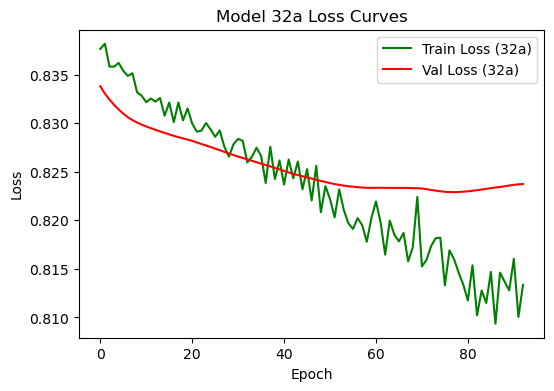

In [34]:
#Loss Curves for model_32a
plt.figure(figsize=(6, 4))
plt.plot(train_32a, label='Train Loss (32a)', color='green')
plt.plot(val_32a, label='Val Loss (32a)', color='red')
plt.title('Model 32a Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

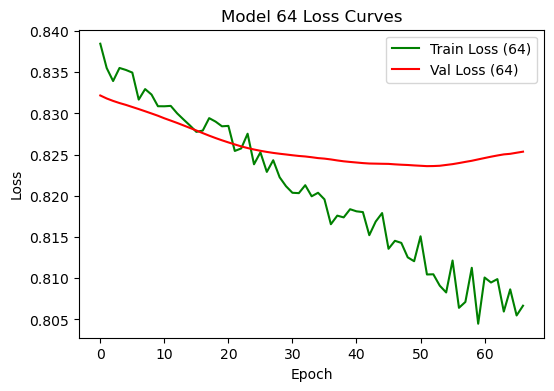

In [35]:
# Loss Curves for model_64
plt.figure(figsize=(6, 4))
plt.plot(train_64, label='Train Loss (64)', color='green')
plt.plot(val_64, label='Val Loss (64)', color='red')
plt.title('Model 64 Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

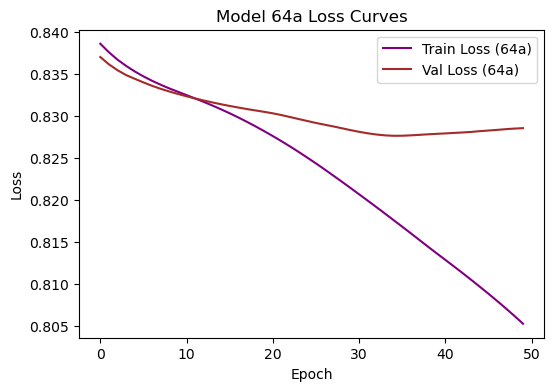

In [36]:
#Plotting the loss curves for model_64a
plt.figure(figsize=(6, 4))
plt.plot(train_64a, label='Train Loss (64a)', color='purple')
plt.plot(val_64a, label='Val Loss (64a)', color='brown')
plt.title('Model 64a Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [37]:
# Evaluate the model_32
model_32.eval()
with torch.no_grad():
    y_pred_prob = model_32(X_test_tensor)
    y_pred = (torch.sigmoid(y_pred_prob) > 0.5).float()


In [38]:
#Evaluate the model_32a
model_32a.eval()
with torch.no_grad():
    y_pred_prob_32a = model_32a(X_test_tensor)
    y_pred_32a = (torch.sigmoid(y_pred_prob_32a) > 0.5).float()

In [39]:
# Evaluate the model_64
model_64.eval()
with torch.no_grad():
    y_pred_prob_64 = model_64(X_test_tensor)
    y_pred_64 = (torch.sigmoid(y_pred_prob_64) > 0.5).float()

In [40]:
#Evaluate the model_64a
model_64a.eval()
with torch.no_grad():
    y_pred_prob_64a = model_64a(X_test_tensor)
    y_pred_64a = (torch.sigmoid(y_pred_prob_64a) > 0.5).float()

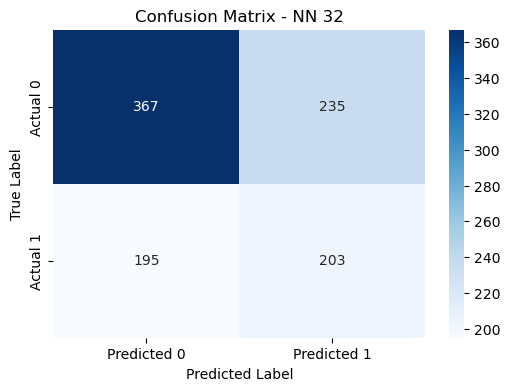


 Model 32 Classification Report:
              precision    recall  f1-score   support

         0.0       0.65      0.61      0.63       602
         1.0       0.46      0.51      0.49       398

    accuracy                           0.57      1000
   macro avg       0.56      0.56      0.56      1000
weighted avg       0.58      0.57      0.57      1000



In [41]:
# Display confusion matrix to analyze classification performance
conf_matrix_32 = confusion_matrix(y_test_tensor.numpy(), y_pred.numpy())

#print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_32, annot=True, fmt='d', cmap='Blues',xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix - NN 32")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
print("\n Model 32 Classification Report:")
print(classification_report(y_test_tensor.numpy(), y_pred.numpy()))

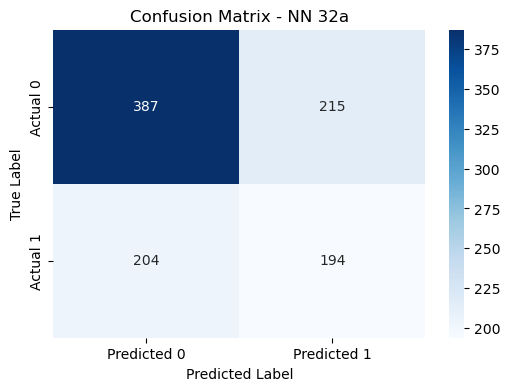


 Model 32a Classification Report:
              precision    recall  f1-score   support

         0.0       0.65      0.64      0.65       602
         1.0       0.47      0.49      0.48       398

    accuracy                           0.58      1000
   macro avg       0.56      0.57      0.56      1000
weighted avg       0.58      0.58      0.58      1000



In [42]:
#Confusion matrix for model_32a
conf_matrix_32a = confusion_matrix(y_test_tensor.numpy(), y_pred_32a.numpy())
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_32a, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix - NN 32a")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
print("\n Model 32a Classification Report:")
print(classification_report(y_test_tensor.numpy(), y_pred_32a.numpy()))


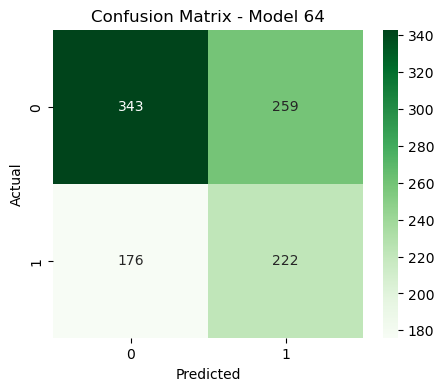

Model 64 Classification Report
              precision    recall  f1-score   support

         0.0       0.66      0.57      0.61       602
         1.0       0.46      0.56      0.51       398

    accuracy                           0.56      1000
   macro avg       0.56      0.56      0.56      1000
weighted avg       0.58      0.56      0.57      1000



In [43]:
conf_matrix_64 = confusion_matrix(y_test_tensor.numpy(), y_pred_64.numpy())

plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix_64, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Model 64")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Model 64 Classification Report")
print(classification_report(y_test_tensor.numpy(), y_pred_64.numpy()))

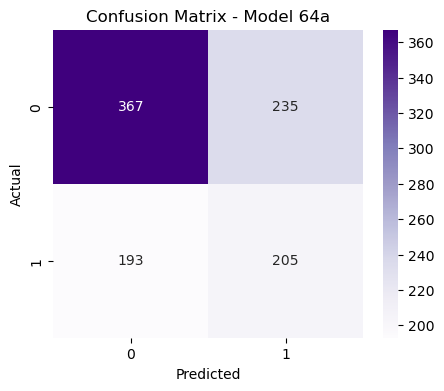

Model 64a Classification Report
              precision    recall  f1-score   support

         0.0       0.66      0.61      0.63       602
         1.0       0.47      0.52      0.49       398

    accuracy                           0.57      1000
   macro avg       0.56      0.56      0.56      1000
weighted avg       0.58      0.57      0.57      1000



In [44]:
#Confusion matrix for model_64a
conf_matrix_64a = confusion_matrix(y_test_tensor.numpy(), y_pred_64a.numpy())
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix_64a, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Model 64a")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("Model 64a Classification Report")
print(classification_report(y_test_tensor.numpy(), y_pred_64a.numpy()))


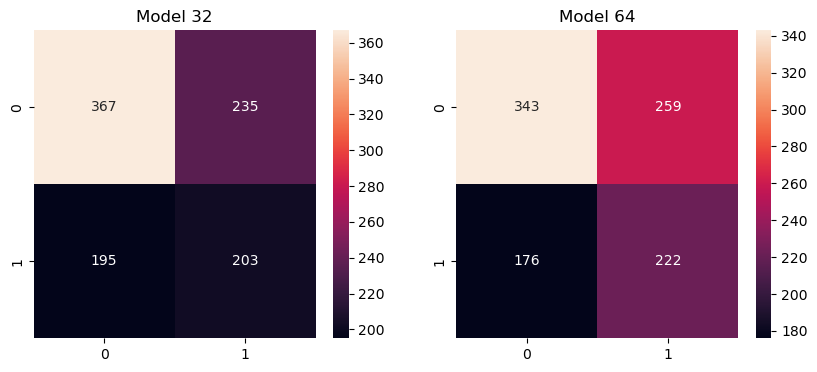

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(conf_matrix_32, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Model 32")

sns.heatmap(conf_matrix_64, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Model 64")

plt.show()

Tabnet

In [46]:
X_train_tabnet = X_train_processed.astype("float32")
X_test_tabnet = X_test_processed.astype("float32")

y_train_tabnet = y_train.to_numpy().ravel()
y_test_tabnet = y_test.to_numpy().ravel()

In [47]:
X_train_tabnet, X_val_tabnet, y_train_tabnet, y_val_tabnet = train_test_split(
    X_train_tabnet,
    y_train_tabnet,
    test_size=0.2,
    random_state=42
)

In [48]:
# Define TabNet Classifier
tabnet = TabNetClassifier(
    n_d=16, # Dimension of the decision prediction layer
    n_a=16, # Dimension of the attention embedding for each mask
    n_steps=5,   # 7 biraz agresif, genelde 3-5 daha stabil
    gamma=1.5, # Relaxation parameter for the sparsemax
    lambda_sparse=1e-4, # Sparsity regularization strength
    verbose=10
)

tabnet.fit(
    X_train_tabnet, y_train_tabnet,
    eval_set=[(X_val_tabnet, y_val_tabnet)],
    eval_metric=['logloss', 'auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)


c:\Users\kabir\miniforge3\envs\DSPy2025\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.98139 | val_0_logloss: 0.68338 | val_0_auc: 0.53208 |  0:00:02s
epoch 10 | loss: 0.67405 | val_0_logloss: 0.67369 | val_0_auc: 0.50261 |  0:00:18s

Early stopping occurred at epoch 13 with best_epoch = 3 and best_val_0_auc = 0.53763


c:\Users\kabir\miniforge3\envs\DSPy2025\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [49]:
y_probab = tabnet.predict_proba(X_test_tabnet)[:, 1]
y_pred = (y_probab >= 0.5).astype(int)

In [50]:
y_pred_tabnet = tabnet.predict(X_test_tabnet)

In [51]:
tabnet.history['loss']
tabnet.history['val_0_auc']

[0.5320764855442845,
 0.4945184923068858,
 0.4893056538491783,
 0.5376267987732956,
 0.48397158659012873,
 0.5179910094099762,
 0.5039415742706613,
 0.5178042515268276,
 0.519511284107887,
 0.517797698618647,
 0.5026146103640795,
 0.49664163455741656,
 0.5207039133967655,
 0.5328530051636916]

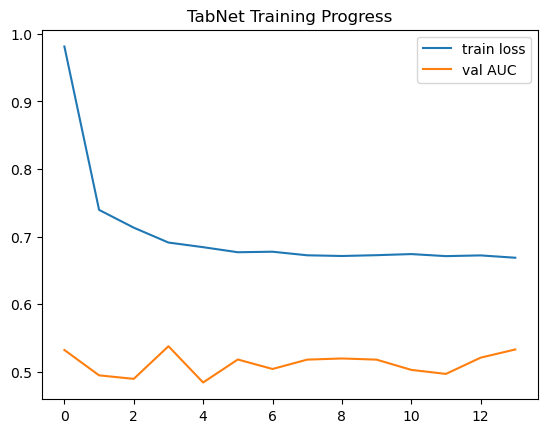

In [52]:
plt.plot(tabnet.history['loss'], label='train loss')
plt.plot(tabnet.history['val_0_auc'], label='val AUC')

plt.legend()
plt.title("TabNet Training Progress")
plt.show()

In [53]:
y_pred = tabnet.predict(X_test_tabnet)

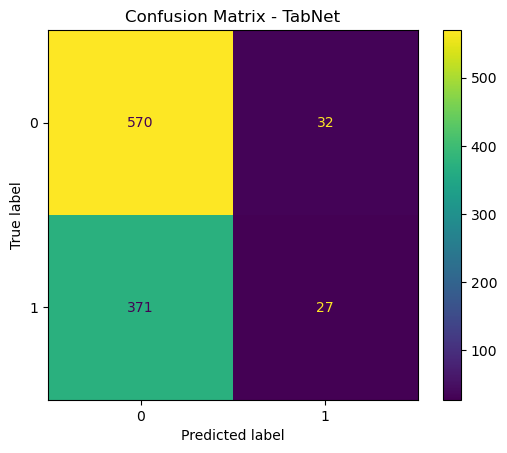

Classification Report - TabNet
              precision    recall  f1-score   support

           0       0.61      0.95      0.74       602
           1       0.46      0.07      0.12       398

    accuracy                           0.60      1000
   macro avg       0.53      0.51      0.43      1000
weighted avg       0.55      0.60      0.49      1000



In [54]:
# Evaluate the model
cm = confusion_matrix(y_test_tabnet, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - TabNet")
plt.show()


print("Classification Report - TabNet")
print(classification_report(y_test_tabnet, y_pred))

ROC-AUC Curve(Model Performance)

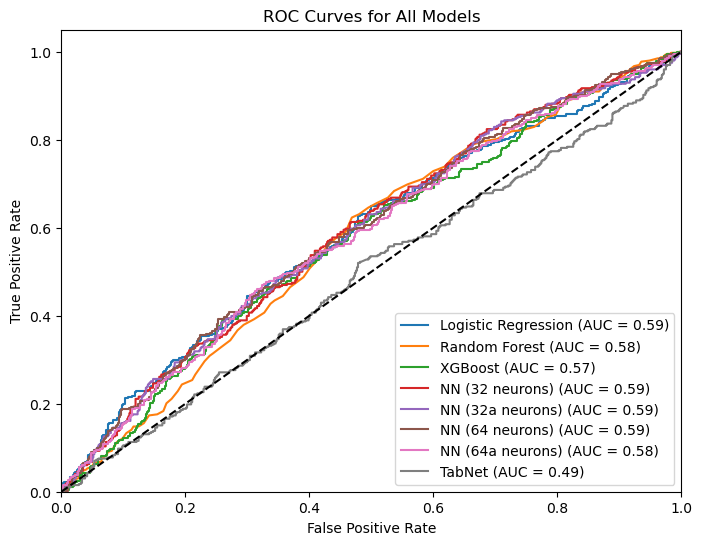


--- Classification Report Overview ---
                 Model  Accuracy  Precision  Recall  F1-Score     AUC
0  Logistic Regression     0.574     0.4680  0.5151    0.4904  0.5880
1        Random Forest     0.579     0.4398  0.2111    0.2852  0.5757
2              XGBoost     0.593     0.4807  0.2814    0.3550  0.5740
3      NN (32 neurons)     0.570     0.4635  0.5101    0.4856  0.5913
4     NN (32a neurons)     0.581     0.4743  0.4874    0.4808  0.5913
5      NN (64 neurons)     0.565     0.4615  0.5578    0.5051  0.5910
6     NN (64a neurons)     0.572     0.4659  0.5151    0.4893  0.5910
7               TabNet     0.597     0.4576  0.0678    0.1182  0.4930


In [55]:
# Pipelines
logistic_pipeline = divorce_model1
random_forest_pipeline = divorce_model2
xgb_pipeline = divorce_model3

plt.figure(figsize=(8, 6))

# Logistic Regression
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')

# Random Forest
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')

# XGBoost
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})')


# Neural Network (32)
model_32.eval()
with torch.no_grad():
    y_prob_nn_32 = torch.sigmoid(model_32(X_test_tensor)).numpy().ravel()

fpr_nn_32, tpr_nn_32, _ = roc_curve(y_test_tensor.numpy(), y_prob_nn_32)
auc_nn_32 = auc(fpr_nn_32, tpr_nn_32)
plt.plot(fpr_nn_32, tpr_nn_32, label=f'NN (32 neurons) (AUC = {auc_nn_32:.2f})')


#Neural Network (32a)
model_32a.eval()
with torch.no_grad():
    y_prob_nn_32a = torch.sigmoid(model_32a(X_test_tensor)).numpy().ravel()
fpr_nn_32a, tpr_nn_32a, _ = roc_curve(y_test_tensor.numpy(), y_prob_nn_32a)
auc_nn_32a = auc(fpr_nn_32a, tpr_nn_32a)
plt.plot(fpr_nn_32a, tpr_nn_32a, label=f'NN (32a neurons) (AUC = {auc_nn_32a:.2f})')

# Neural Network (64)
model_64.eval()
with torch.no_grad():
    y_prob_nn_64 = torch.sigmoid(model_64(X_test_tensor)).numpy().ravel()

fpr_nn_64, tpr_nn_64, _ = roc_curve(y_test_tensor.numpy(), y_prob_nn_64)
auc_nn_64 = auc(fpr_nn_64, tpr_nn_64)
plt.plot(fpr_nn_64, tpr_nn_64, label=f'NN (64 neurons) (AUC = {auc_nn_64:.2f})')

#Neural Network (64a)
model_64a.eval()
with torch.no_grad():
    y_prob_nn_64a = torch.sigmoid(model_64a(X_test_tensor)).numpy().ravel()
fpr_nn_64a, tpr_nn_64a, _ = roc_curve(y_test_tensor.numpy(), y_prob_nn_64a)
auc_nn_64a = auc(fpr_nn_64a, tpr_nn_64a)
plt.plot(fpr_nn_64a, tpr_nn_64a, label=f'NN (64a neurons) (AUC = {auc_nn_64a:.2f})')


# TabNet
y_prob_tabnet = tabnet.predict_proba(X_test_tabnet)[:, 1]

fpr_tabnet, tpr_tabnet, _ = roc_curve(y_test_tabnet, y_prob_tabnet)
auc_tabnet = auc(fpr_tabnet, tpr_tabnet)

plt.plot(fpr_tabnet, tpr_tabnet, label=f'TabNet (AUC = {auc_tabnet:.2f})')

# ROC Plot Settings
plt.plot([0, 1], [0, 1], 'k--')  # random baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Predictions
models = {
    'Logistic Regression': logistic_pipeline.predict(X_test),
    'Random Forest': random_forest_pipeline.predict(X_test),
    'XGBoost': xgb_pipeline.predict(X_test),
    'NN (32 neurons)': (y_prob_nn_32 >= 0.5).astype(int),
    'NN (32a neurons)': (y_prob_nn_32a >= 0.5).astype(int),
    'NN (64 neurons)': (y_prob_nn_64 >= 0.5).astype(int),
    'NN (64a neurons)': (y_prob_nn_64a >= 0.5).astype(int),
    'TabNet': y_pred_tabnet
}

y_test_np = y_test.values

summary = []

for name, y_pred in models.items():
    acc = accuracy_score(y_test_np, y_pred)
    prec = precision_score(y_test_np, y_pred)
    rec = recall_score(y_test_np, y_pred)
    f1 = f1_score(y_test_np, y_pred)

    if name == 'Logistic Regression':
        auc_val = auc_lr
    elif name == 'Random Forest':
        auc_val = auc_rf
    elif name == 'XGBoost':
        auc_val = auc_xgb
    
    elif name == 'TabNet':
        auc_val = auc_tabnet
        
    elif '32' in name:
        auc_val = auc_nn_32
    else:
        auc_val = auc_nn_64
        

    summary.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc_val
    })

summary_df = pd.DataFrame(summary)

print("\n--- Classification Report Overview ---")
print(summary_df.round(4))